# Comparison between Decision Trees, Bagging, Random Forests & Boosting (with Grid Search)

### This example applies all these four algorithms with Grid Searching to the same dataset: GlaucomaM.csv

Note: Remember, the goal for this exercise is not to built the best model but to practice and understand the code

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn import metrics
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_recall_curve, confusion_matrix, recall_score, precision_score
from sklearn.model_selection import cross_val_score

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We create some helper functions to display all the results at once

In [25]:
def plot_importances (model):
    importances = model.feature_importances_
    feature_names = np.array(model.feature_names_in_)

    mask = importances > 0
    filtered_importances = importances[mask]
    filtered_feature_names = feature_names[mask]

    sorted_indexes = np.argsort(filtered_importances)[::-1]
    sorted_importances = filtered_importances[sorted_indexes]
    sorted_feature_names = filtered_feature_names[sorted_indexes]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(sorted_importances)), sorted_importances, align='center')

    plt.xticks(range(len(sorted_importances)), sorted_feature_names, rotation=90)
    plt.xlabel("Features (importance >0)")
    plt.ylabel("Importance")
    plt.title("Relative feature importances (from 0 to 1)")

    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{sorted_importances[i]:.2f}', ha='center', va='bottom')

    plt.show()

In [26]:
def ROC_curve(model, X_data, Y_data):
    pred_prob = model.predict_proba(X_data) #probability of being in both groups
    prob_malign = [p[1] for p in pred_prob] #probability of being in the malign group
    auc = roc_auc_score(Y_data, prob_malign)

    print("ROC AUC score: {:.2%}".format(auc))

    # AUC Calculations - false positive rates, true positive rates and thresholds
    fpr, tpr, thresholds = metrics.roc_curve(Y_data, prob_malign, pos_label=1)
    fig, ax = plt.subplots(1, 1)
    ax.plot(fpr, tpr, label="ROC")
    ax.plot([0, 1], [0, 1],linestyle='--', label="Random model")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_box_aspect(1)
    ax.legend()
    plt.show()

In [27]:
def recall_precision(model, X_data, Y_data):
    prob_pred = model.predict_proba(X_data)[:, 1]
    thresholds = np.arange(0.0, 1.0, step=0.01)
    recall_scores = [metrics.recall_score(Y_data, prob_pred > t) for t in thresholds]
    precis_scores = [metrics.precision_score(Y_data, prob_pred > t, zero_division=0) for t in thresholds]
    fig, ax = plt.subplots(1, 1)
    ax.plot(thresholds, recall_scores, label="Recall @ t")
    ax.plot(thresholds, precis_scores, label="Precision @ t")
    ax.axvline(0.5, c="gray", linestyle="--", label="Default Threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric @ Threshold")
    ax.set_box_aspect(1)
    ax.legend()
    plt.show()

In [28]:
def results(model, X_data=None, Y_data=None):
    if X_data is None: X_data = X_test
    if Y_data is None: Y_data = Y_test
    plot_importances (model)
    ROC_curve(model, X_data, Y_data)
    recall_precision(model, X_data, Y_data)

In [29]:
data = pd.read_csv("/content/drive/MyDrive/IE/Courses/ML_II/Decision trees and RF/RF/GlaucomaM.csv")
acc="accuracy" # our metric for Grid Searching

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['Class'] = 1-encoder.fit_transform(data['Class']) # this is just to make glaucoma = 1
data

,ag,at,as,an,ai,eag,eat,eas,ean,eai,...,tmt,tms,tmn,tmi,mr,rnf,mdic,emd,mv,Class
0,2.220,0.354,0.580,0.686,0.601,1.267,0.336,0.346,0.255,0.331,...,-0.018,-0.230,-0.510,-0.158,0.841,0.410,0.137,0.239,0.035,0
1,2.681,0.475,0.672,0.868,0.667,2.053,0.440,0.520,0.639,0.454,...,-0.014,-0.165,-0.317,-0.192,0.924,0.256,0.252,0.329,0.022,0
2,1.979,0.343,0.508,0.624,0.504,1.200,0.299,0.396,0.259,0.246,...,-0.097,-0.235,-0.337,-0.020,0.795,0.378,0.152,0.250,0.029,0
3,1.747,0.269,0.476,0.525,0.476,0.612,0.147,0.017,0.044,0.405,...,-0.035,-0.449,-0.217,-0.091,0.746,0.200,0.027,0.078,0.023,0
4,2.990,0.599,0.686,1.039,0.667,2.513,0.543,0.607,0.871,0.492,...,-0.105,0.084,-0.012,-0.054,0.977,0.193,0.297,0.354,0.034,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,2.801,0.481,0.729,0.888,0.704,1.841,0.312,0.550,0.583,0.396,...,-0.180,-0.224,-0.085,-0.006,0.945,0.121,0.182,0.276,0.033,1
192,1.698,0.265,0.449,0.530,0.454,1.128,0.211,0.281,0.286,0.351,...,-0.137,-0.209,-0.289,0.043,0.736,0.273,0.207,0.312,0.036,1
193,2.124,0.402,0.514,0.697,0.511,1.595,0.369,0.430,0.323,0.473,...,-0.071,-0.048,-0.278,0.048,0.823,0.088,0.174,0.231,0.028,1
194,2.039,0.374,0.491,0.675,0.500,1.561,0.362,0.397,0.316,0.485,...,0.187,0.026,-0.126,0.167,0.808,0.010,0.272,0.355,0.023,1


In [30]:
X = data.loc[:, data.columns != 'Class']
y = data['Class']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y) # note the stratify parameter

print("Number of predictors: ", len(X))
data

Number of predictors:  196


,ag,at,as,an,ai,eag,eat,eas,ean,eai,...,tmt,tms,tmn,tmi,mr,rnf,mdic,emd,mv,Class
0,2.220,0.354,0.580,0.686,0.601,1.267,0.336,0.346,0.255,0.331,...,-0.018,-0.230,-0.510,-0.158,0.841,0.410,0.137,0.239,0.035,0
1,2.681,0.475,0.672,0.868,0.667,2.053,0.440,0.520,0.639,0.454,...,-0.014,-0.165,-0.317,-0.192,0.924,0.256,0.252,0.329,0.022,0
2,1.979,0.343,0.508,0.624,0.504,1.200,0.299,0.396,0.259,0.246,...,-0.097,-0.235,-0.337,-0.020,0.795,0.378,0.152,0.250,0.029,0
3,1.747,0.269,0.476,0.525,0.476,0.612,0.147,0.017,0.044,0.405,...,-0.035,-0.449,-0.217,-0.091,0.746,0.200,0.027,0.078,0.023,0
4,2.990,0.599,0.686,1.039,0.667,2.513,0.543,0.607,0.871,0.492,...,-0.105,0.084,-0.012,-0.054,0.977,0.193,0.297,0.354,0.034,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,2.801,0.481,0.729,0.888,0.704,1.841,0.312,0.550,0.583,0.396,...,-0.180,-0.224,-0.085,-0.006,0.945,0.121,0.182,0.276,0.033,1
192,1.698,0.265,0.449,0.530,0.454,1.128,0.211,0.281,0.286,0.351,...,-0.137,-0.209,-0.289,0.043,0.736,0.273,0.207,0.312,0.036,1
193,2.124,0.402,0.514,0.697,0.511,1.595,0.369,0.430,0.323,0.473,...,-0.071,-0.048,-0.278,0.048,0.823,0.088,0.174,0.231,0.028,1
194,2.039,0.374,0.491,0.675,0.500,1.561,0.362,0.397,0.316,0.485,...,0.187,0.026,-0.126,0.167,0.808,0.010,0.272,0.355,0.023,1


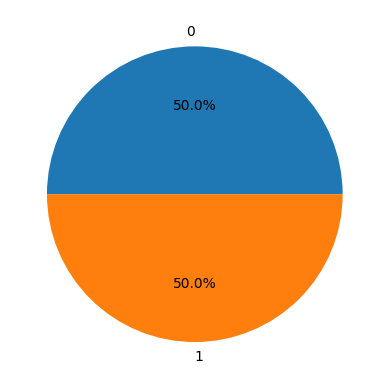

In [31]:
unique, counts = np.unique(data["Class"], return_counts=True)
plt.pie(counts, labels=unique, autopct='%.1f%%');

### 1 Decision Trees with Grid Search

In [32]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

param_grid = {
    'min_samples_leaf' :range(2,6),
    'max_depth': range(2,8),
}

tree_grid = GridSearchCV(model, param_grid, scoring=acc, cv=5 , n_jobs=1, verbose=2)
tree_grid.fit(X_train,Y_train)

print("Best param: ", tree_grid.best_params_)

tree_pruned = DecisionTreeClassifier(**tree_grid.best_params_, criterion="entropy")
tree_pruned.fit(X_train, Y_train)

predictions = tree_pruned.predict(X_test)
accDTGrid=accuracy_score(Y_test, predictions)

print("Accuracy of Test set (pruned) = {0:.2%}".format(accDTGrid))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ....................max_depth=2, min_samples_leaf=2; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=2; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=2; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=2; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=2; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=3; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=3; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=3; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=3; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=3; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=4; total time=   0.0s
[CV] END ....................max_depth=2, min_s

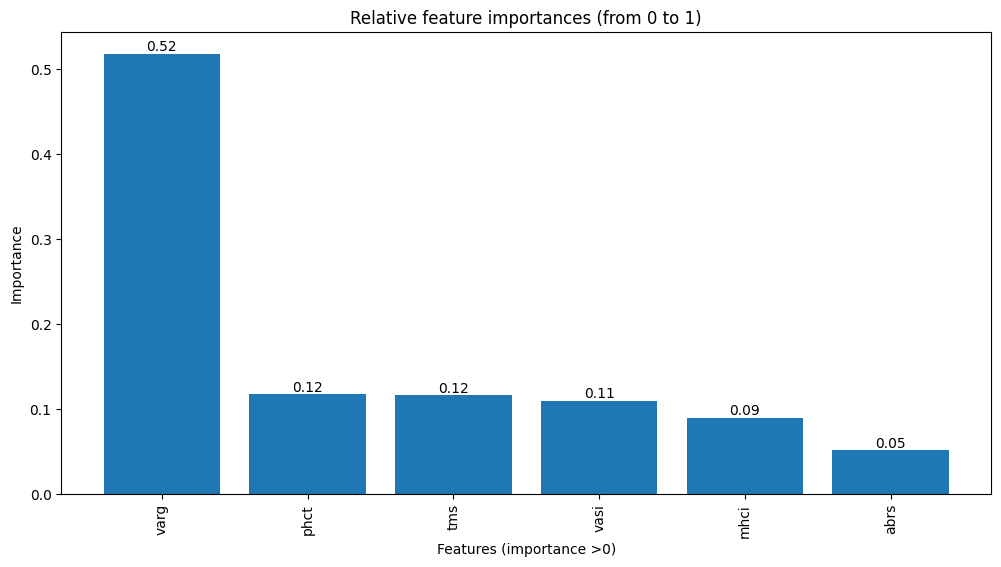

ROC AUC score: 85.92%


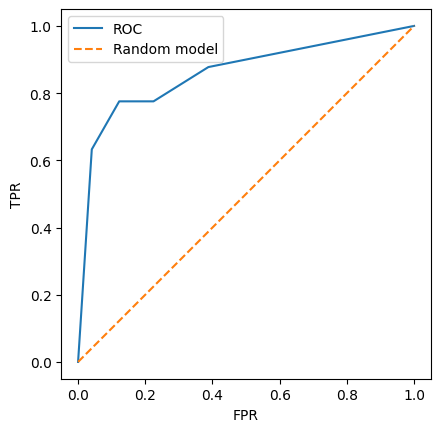

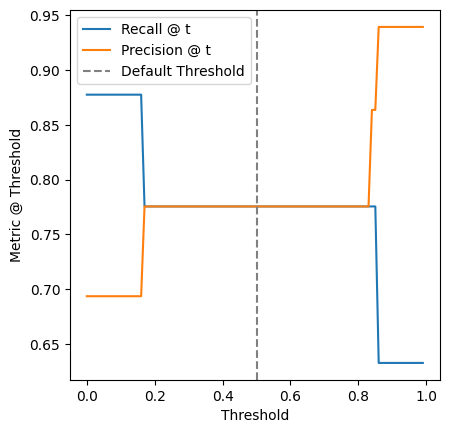

In [33]:
results(tree_pruned)

### 2 RF with Grid Search

We apply a Random Forest, and estimate the best parameters using GridSearch Cross validation.
<br> **n_estimators** is the number of trees. Usually 100-500.  <br>
**max_depth** determines the max depth of all trees. Deeper trees = more variance, shallower = more bias. <br>
**min_samples_leaf**: Minimum samples needed in each leaf.



One of the defining features of RF is that it not all fetures are considered at every split. This allows RF to consider other paths, and not depend solely on the strongest predictors. The default **max_features** is the sqrt of the number of predictors.
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [12]:
param_grid = {
    'min_samples_leaf' :[2,3,4,5],
    'max_features' : ["log2", "sqrt"],
    'max_depth': range(2,8)
}

model_RFgrid = GridSearchCV(RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42), # Added random_state for reproducibility
                              param_grid=param_grid,
                              cv=5,
                              scoring=acc,
                              verbose=0)

model_RFgrid.fit(X_train,Y_train)
print("Best param: ", model_RFgrid.best_params_)

# Use the best estimator directly from GridSearchCV
modelRFgrid_best_estimator = model_RFgrid.best_estimator_

print("Accuracy OOB set - RF with Grid Searching: {0:.2%}".format(modelRFgrid_best_estimator.oob_score_))

predictions = modelRFgrid_best_estimator.predict(X_test)
accRFGrid=accuracy_score(Y_test, predictions)

print("Accuracy of Test set = {0:.2%}".format(accRFGrid))

Best param:  {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2}
Accuracy OOB set - RF with Grid Searching: 81.63%
Accuracy of Test set = 84.69%


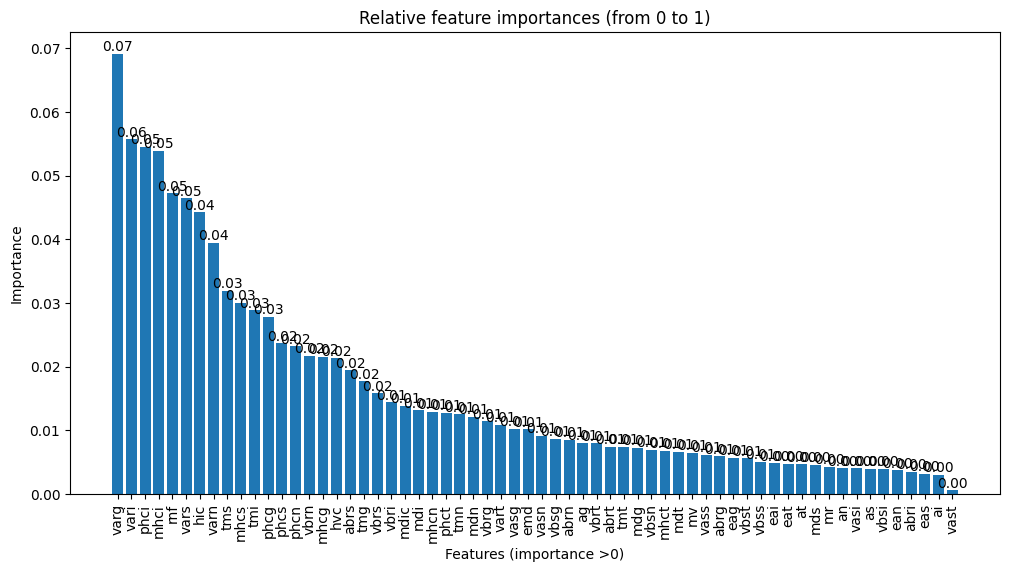

ROC AUC score: 91.71%


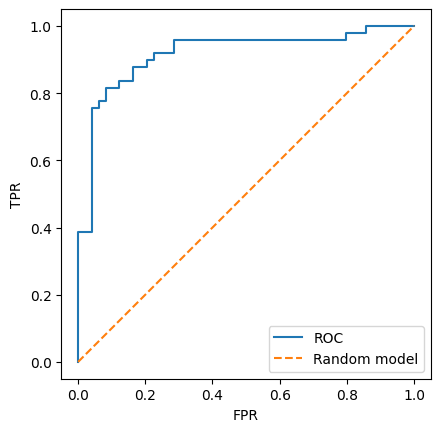

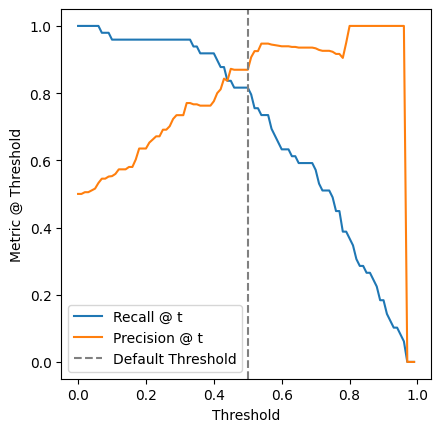

In [13]:
results (modelRFgrid_best_estimator)

### 3 Boosting with Grid Search

xboost offers L1 and L2 regularizations with the parameter reg_alpha. These algorithms incorporate these penalty terms into their objective functions when constructing individual trees, allowing them to perform explicit feature sparsity and shrink less important features towards zero.

In [14]:
import xgboost as xgb

data_dmatrix = xgb.DMatrix(data=X_train, label=Y_train)

XGB = XGBClassifier(n_estimators=20)
XGB.fit(X_train,Y_train)

param_grid = {
    'n_estimators': [20, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'reg_alpha': [0.3, 0.5, 1],
    'subsample': [0.8, 1]
}

xgbGrid = GridSearchCV(XGB, param_grid, cv = 5, scoring=acc, verbose=0)
xgbGrid.fit(X_train, Y_train)

print("Best set of hyperparameters: ", xgbGrid.best_params_)

Best set of hyperparameters:  {'learning_rate': 0.2, 'n_estimators': 100, 'reg_alpha': 1, 'subsample': 0.8}


In [15]:
XGB = XGBClassifier(**xgbGrid.best_params_)
XGB.fit(X_train, Y_train)

predictions = XGB.predict(X_test)
accBoostGrid=accuracy_score(Y_test, predictions)

print("Accuracy of Test set = {0:.2%}".format(accBoostGrid))

Accuracy of Test set = 79.59%


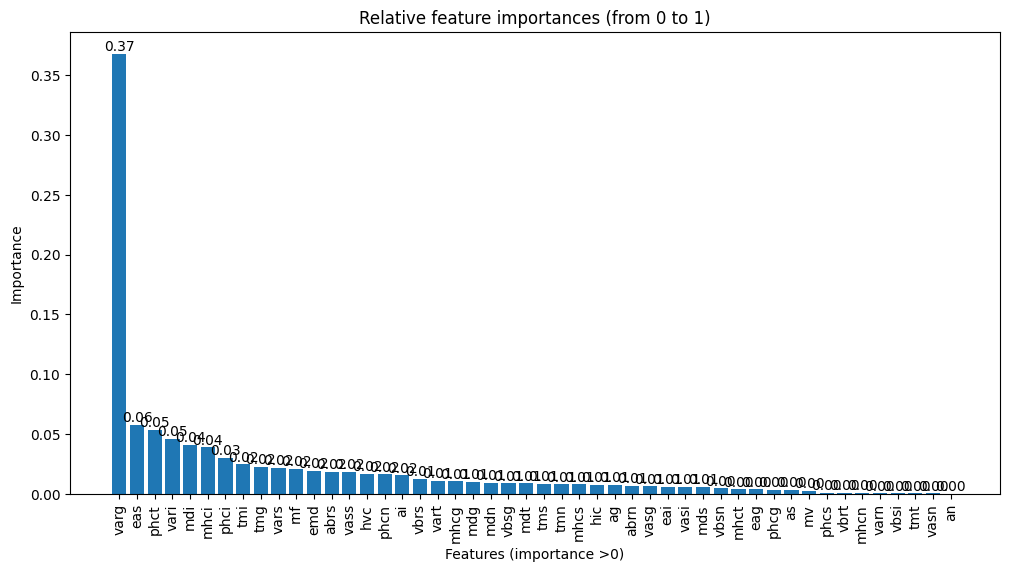

ROC AUC score: 87.67%


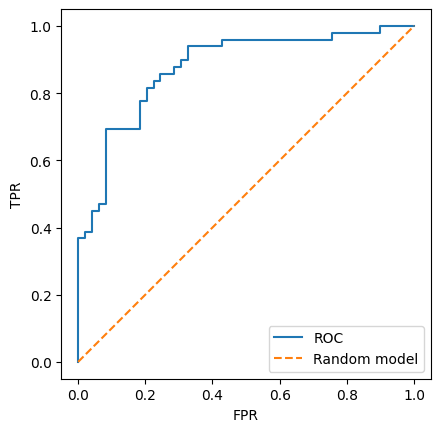

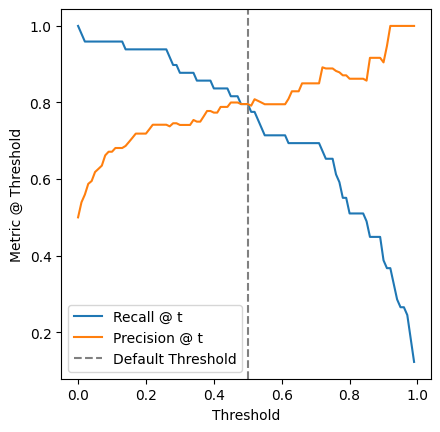

In [16]:
results (XGB)

## Summary of Results

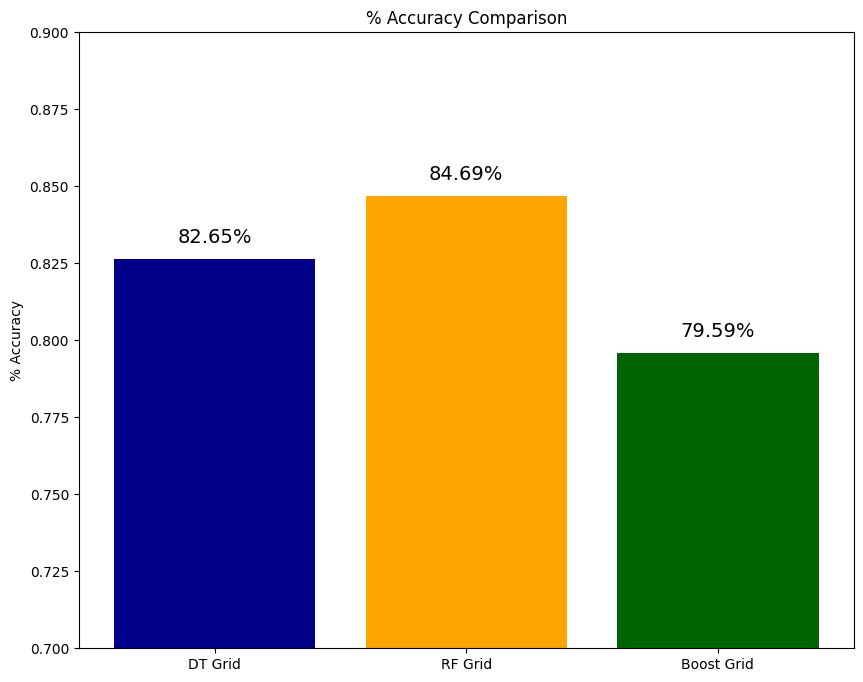

In [17]:
categ = ['DT Grid', 'RF Grid', 'Boost Grid']
values = [accDTGrid, accRFGrid, accBoostGrid]
colors = ['darkblue', 'orange', 'darkgreen']

plt.figure(figsize=(10,8))
plt.bar(categ, values, color=colors)
plt.ylim(.7, .9)

plt.xlabel('')
plt.ylabel('% Accuracy')
plt.title('% Accuracy Comparison')

for i, v in enumerate(values):
    plt.text(i, v+0.01, "{0:.2%}".format(v) , ha='center', va='top', fontsize=14)

plt.show()

## Reflection questions

1. What is the utility of the OOB score in Random Forests.
2. How do the `max_depth` and `min_samples_leaf` parameters affect the complexity and performance of a Decision Tree and Random Forest?
3. Four-eight predictors are more important than the others according to RF. Could we run a RF algorithm based on those highly important predictors?
4. We have seen other accuracy metrics such as recall and precision. Why is acuracy appropriate in this case?

5. Feature importance in RF is based on how often a predictor is chosen to split the data. If two features are very important and very correlated, this process will dilute their importance. Implement a recursive feature elimination in the RF to drop some correlated (and also unimportant) features before hand.

In [34]:
print("Best param: ", model_RFgrid.best_params_)


Best param:  {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2}


https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html

from sklearn.feature_selection import RFECV

In [19]:
print('Selected features: %s' % list(X_train.columns[rfecv_model.support_]))

Selected features: ['abrs', 'hic', 'mhcg', 'mhcs', 'mhci', 'phcg', 'phcn', 'phci', 'hvc', 'vasn', 'varg', 'vars', 'varn', 'vari', 'tmg', 'tms', 'tmi', 'rnf']


We can now run the model with the most important predictors and the selected hyperparameters.

Alternatively, you can ram through all the combinations of features and hyperparameters, but this will take time.

## 5 Apply Grid Search for RFE and RF Parameters
Combine RFE with GridSearchCV to tune both the RFE parameters (e.g., step size, number of features) and the Random Forest hyperparameters (e.g., max_depth, min_samples_leaf) simultaneously on the training data.

This will take time, do it at home.


In [22]:
#from sklearn.pipeline import Pipeline
#from sklearn.feature_selection import RFE

# Create an instance of RandomForestClassifier for RFE and the final classifier
#rf_estimator = RandomForestClassifier(random_state=42)

# Construct the Pipeline
#pipeline = Pipeline([
#    ('rfe', RFE(estimator=rf_estimator)),
#    ('clf', RandomForestClassifier(random_state=42))
#])

# Define a param_grid for GridSearchCV
#param_grid = {
#    'rfe__n_features_to_select': [10, 15, 18, 20, 25],
#    'rfe__step': [1, 2],
#    'clf__max_depth': [3, 5, 7],
#    'clf__min_samples_leaf': [2, 4]
#}

# Initialize GridSearchCV
#grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
#grid_search.fit(X_train, Y_train)

# Print the best parameters
#print("Best parameters found by GridSearchCV:")
#print(grid_search.best_params_)